In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import matplotlib.pyplot as plt
import tqdm

import transformer_lens

/Users/samswitz/miniforge3/envs/sae/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
metrics = pd.read_csv("training_metrics.csv")

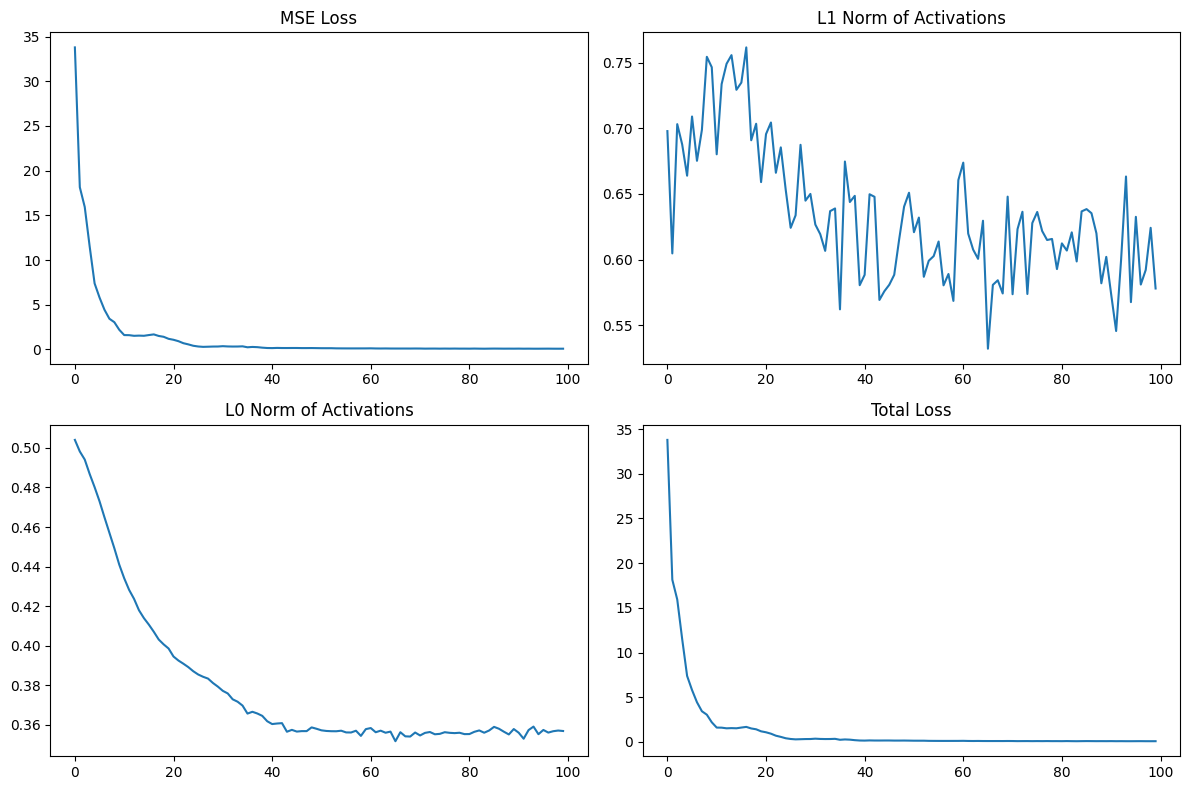

In [8]:
# plot the metrics
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [13]:
from sae import SparseAutoEncoder
from datasets import load_dataset

# Load model (only needed for tokenization, no forward pass)
model = transformer_lens.HookedTransformer.from_pretrained("pythia-70m")

# Load saved SAE
d, m = 512, 512 * 8
sae = SparseAutoEncoder(d=d, m=m)
sae.load_state_dict(torch.load("sae_model.pt"))
sae.eval()

# Re-tokenize the same texts to get token strings (no forward pass)
NUM_TEXTS = 500
ACTIVATIONS_PATH = f"activations_{NUM_TEXTS}.pt"
dataset = load_dataset("openwebtext", split="train", streaming=True)

# Load saved activations and run through SAE encoder
activations = torch.load(ACTIVATIONS_PATH)
with torch.no_grad():
    all_feature_acts = sae.encoder(activations)

all_tokens = []
all_contexts = []
for i, example in enumerate(dataset):
    if i >= NUM_TEXTS:
        break
    text = example["text"][:512]
    tokens = model.to_str_tokens(text)
    for t in tokens:
        all_tokens.append(t)
        all_contexts.append(text)

print(f"Total tokens: {len(all_tokens)}")
print(f"Feature activations shape: {all_feature_acts.shape}")
assert len(all_tokens) == all_feature_acts.shape[0], "Token count doesn't match activation count!"

Loaded pretrained model pythia-70m into HookedTransformer
Total tokens: 58697
Feature activations shape: torch.Size([58697, 4096])


In [14]:
def inspect_feature(feature_idx, k=10):
    acts = all_feature_acts[:, feature_idx]
    top_vals, top_idxs = acts.topk(k)
    
    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(top_vals, top_idxs):
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(2)
print()
inspect_feature(100)

Feature 2 — top 10 activating tokens:

  0.047  token=           'gr'   context: One family says the ratings-grabbing reality show "Extreme Makeover: Home Editio
  0.043  token=    ' straight'   context: Stacey Tillman, a 47-year-old woman from Sandusky, Ohio, says she has donated ov
  0.017  token=       ' legal'   context: Clarifying The Trustwave CA Policy Update

We've seen a number of comments and q
  0.014  token=      ' atmosp'   context: This view of a full moon was photographed by an Expedition 14 crewmember onboard
  0.001  token=         ' mud'   context: A searcher walks through the debris of a deadly mudslide in Oso, Wash. At least 
  0.000  token=        'utive'   context: Executive summary

This paper reviews the empirical literature on the employment
  0.000  token=            ','   context: Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping
  0.000  token=            '-'   context: Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhin

In [15]:
# Count how many tokens each feature activates on         
feature_counts = (all_feature_acts > 0).sum(dim=0)  # shape (4096,)           
                                                        
# Get the indices of the sparsest (least frequently active) features
# Exclude dead features (count == 0) since those learned nothing
alive_mask = feature_counts > 0
alive_counts = feature_counts.clone()
alive_counts[~alive_mask] = all_feature_acts.shape[0] + 1  # push dead ones to the end

_, sparsest_idxs = alive_counts.sort()

print(f"Dead features: {(~alive_mask).sum().item()} / {all_feature_acts.shape[1]}")
print()
for idx in sparsest_idxs[:10]:
    count = feature_counts[idx].item()
    print(f"Feature {idx}: activates on {count}/{all_feature_acts.shape[0]} tokens ({100*count/all_feature_acts.shape[0]:.1f}%)")
    inspect_feature(idx.item(), k=5)
    print()

Dead features: 665 / 4096

Feature 2019: activates on 1/58697 tokens (0.0%)
Feature 2019 — top 5 activating tokens:

  0.116  token=       ' lands'   context: 2015 brought record passenger traffic to Bush, Hobby

A Southwest Airlines Boein
  0.000  token=            '-'   context: Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping
  0.000  token=            '-'   context: Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping
  0.000  token='<|endoftext|>'   context: Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping
  0.000  token=         'Port'   context: Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping

Feature 962: activates on 1/58697 tokens (0.0%)
Feature 962 — top 5 activating tokens:

  0.002  token=          ' 39'   context: The funeral of Lian Zaher Nasser was held in the Arab-Israeli town of Tira on Ja
  0.000  token=            '-'   context: Port-au-Prince